# Heart Disease Prediction — EDA & Preprocessing

Combined dataset: Cleveland, Hungary, Switzerland, VA Long Beach (920 patients, 16 columns).
Goal: predict the presence of heart disease (binary classification).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/heart_disease_uci.csv')
df.shape

(920, 16)

## 1. Overview

In [2]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,920.0,NaN,NaN,NaN,460.5,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,NaN,NaN,NaN,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
sex,920,2,Male,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,920,4,Cleveland,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,920,4,asymptomatic,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,861.0,NaN,NaN,NaN,132.132404,19.06607,0.0,120.0,130.0,140.0,200.0
chol,890.0,NaN,NaN,NaN,199.130337,110.78081,0.0,175.0,223.0,268.0,603.0
fbs,830,2,False,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,918,3,normal,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,865.0,NaN,NaN,NaN,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0


## 2. Missing values

Missingness is not random: it strongly depends on the hospital (`dataset`) of origin.

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing': missing, 'pct': missing_pct})[missing > 0]

,missing,pct
ca,611,66.4
thal,486,52.8
slope,309,33.6
fbs,90,9.8
oldpeak,62,6.7
trestbps,59,6.4
exang,55,6.0
thalch,55,6.0
chol,30,3.3
restecg,2,0.2


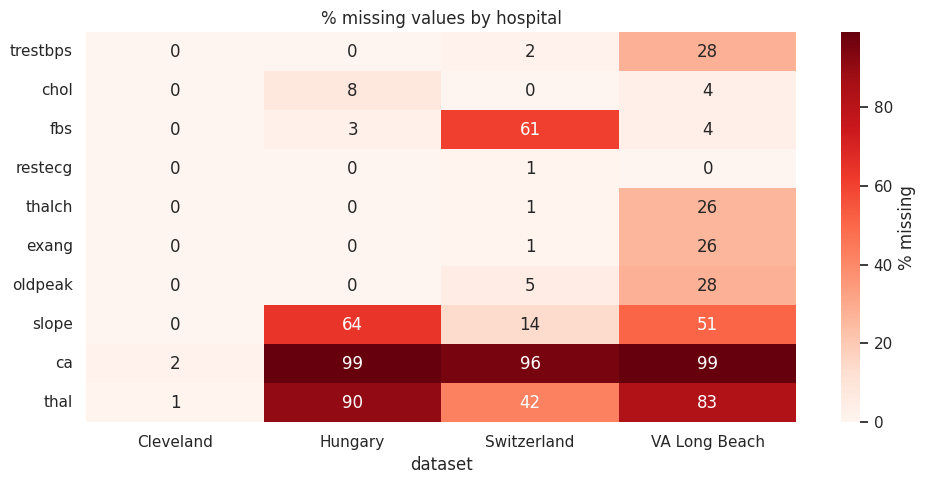

In [6]:
cols_with_na = df.columns[df.isna().any()].tolist()
missing_by_source = df.groupby('dataset')[cols_with_na].apply(lambda x: x.isna().mean()*100).round(1)
plt.figure(figsize=(10,5))
sns.heatmap(missing_by_source.T, annot=True, fmt='.0f', cmap='Reds', cbar_kws={'label': '% missing'})
plt.title("% missing values by hospital")
plt.tight_layout()
plt.savefig('../notebooks/missing_by_hospital.png', dpi=120)
plt.show()

**Key observation**: `ca` and `thal` are missing 90%+ of the time for Hungary/Switzerland/VA (likely not measured at those hospitals), while Cleveland has close to 0% missing. We keep this signal via missingness flags instead of ignoring it.

## 3. Target: presence of heart disease

`num` ranges from 0 (healthy) to 4 (severity). We binarize: `target = 1 if num > 0`.

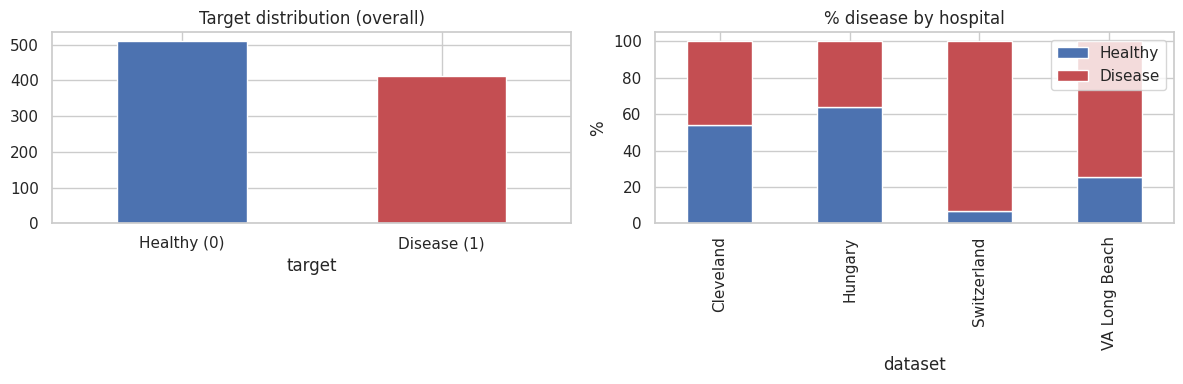

In [7]:
df['target'] = (df['num'] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
df['target'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#C44E52'])
axes[0].set_title('Target distribution (overall)')
axes[0].set_xticklabels(['Healthy (0)', 'Disease (1)'], rotation=0)

pd.crosstab(df['dataset'], df['target'], normalize='index').mul(100).plot(kind='bar', stacked=True, ax=axes[1], color=['#4C72B0','#C44E52'])
axes[1].set_title('% disease by hospital')
axes[1].set_ylabel('%')
axes[1].legend(['Healthy','Disease'])
plt.tight_layout()
plt.savefig('../notebooks/target_distribution.png', dpi=120)
plt.show()

**Observation**: the disease rate varies a lot by hospital (36% at Hungary vs 93% at Switzerland). This is a recruitment/population bias — we'll use `dataset` to stratify the train/test split, but not as a model input feature (to avoid the model learning a shortcut tied to the hospital rather than actual clinical factors).

## 4. Feature engineering: missingness flags

In [8]:
for col in ['ca', 'thal', 'slope']:
    df[f'{col}_missing'] = df[col].isna().astype(int)

df[['ca_missing','thal_missing','slope_missing']].sum()

ca_missing       611
thal_missing     486
slope_missing    309
dtype: int64

## 5. Imputation

Numerical -> median per hospital. Categorical -> mode per hospital (global fallback if a hospital has no value at all).

In [9]:
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
cat_cols = ['fbs', 'restecg', 'exang', 'slope', 'thal']

df_clean = df.copy()

for col in num_cols:
    df_clean[col] = df_clean.groupby('dataset')[col].transform(lambda x: x.fillna(x.median()))
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())  # global fallback

for col in cat_cols:
    mode_fill = lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
    df_clean[col] = df_clean.groupby('dataset')[col].transform(mode_fill)
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode().iloc[0])

df_clean.isna().sum().sum()  # should be 0 (excluding 'num', kept for reference)

np.int64(0)

## 6. Encoding categorical variables

In [10]:
df_clean['sex'] = df_clean['sex'].map({'Male': 1, 'Female': 0})
df_clean['fbs'] = df_clean['fbs'].astype(int)
df_clean['exang'] = df_clean['exang'].astype(int)

df_model = pd.get_dummies(df_clean, columns=['cp', 'restecg', 'slope', 'thal'], drop_first=True)

df_model.head()

,id,age,sex,dataset,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,target,ca_missing,thal_missing,slope_missing,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,1,63,1,Cleveland,145.0,233.0,1,150.0,0,2.3,0.0,0,0,0,0,0,False,False,True,False,False,False,False,False,False
1,2,67,1,Cleveland,160.0,286.0,0,108.0,1,1.5,3.0,2,1,0,0,0,False,False,False,False,False,True,False,True,False
2,3,67,1,Cleveland,120.0,229.0,0,129.0,1,2.6,2.0,1,1,0,0,0,False,False,False,False,False,True,False,False,True
3,4,37,1,Cleveland,130.0,250.0,0,187.0,0,3.5,0.0,0,0,0,0,0,False,True,False,True,False,False,False,True,False
4,5,41,0,Cleveland,130.0,204.0,0,172.0,0,1.4,0.0,0,0,0,0,0,True,False,False,False,False,False,True,True,False


## 7. Train/test split

Stratified by `target` AND by `dataset` (hospital) to keep each hospital's proportions in both sets.

In [11]:
from sklearn.model_selection import train_test_split

drop_cols = ['id', 'num', 'dataset']
X = df_model.drop(columns=drop_cols + ['target'])
y = df_model['target']
strata = df_model['dataset'] + '_' + df_model['target'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=strata
)

X_train.shape, X_test.shape, y_train.mean().round(2), y_test.mean().round(2)

((736, 21), (184, 21), np.float64(0.55), np.float64(0.55))

In [12]:
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)
print("Files saved to data/")

Files saved to data/


## Next step

Additional feature analysis (correlations, distributions by target) then model comparison (LogReg, RF, XGBoost, Extra Trees) — next notebook.